#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?


# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [1]:
!pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.7 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB
SECRET_WORD: I LOVE MMAI


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


In [2]:
# ============================================================
# CIFAR-10 DATASET PREPARATION FOR VISION-LANGUAGE FINE-TUNING
# ============================================================
# We prepare a dataset in the format required by the assignment,
# as described extensively in the cell below.
# We use CIFAR-10 images and convert the classification labels
# into a simple VLM question-answer task.
# ============================================================

# Install required libraries
# !pip install torch torchvision

import os
import json
import random
from torchvision.datasets import CIFAR10
from google.colab import files

# 1. Create dataset directories
os.makedirs("mmai-data/images", exist_ok=True)

# 2. Download CIFAR-10 dataset
dataset = CIFAR10(root=".", download=True)

# 3. Convert CIFAR images into the required format
data_entries = []
NUM_IMAGES = 200   # number of images to include

for i in range(NUM_IMAGES):
    img, label = dataset[i]              # load image + numeric label
    label_name = dataset.classes[label]  # convert label to class name

    # Save image
    image_filename = f"image_{i}.jpg"
    img.save(f"mmai-data/images/{image_filename}")

    # Create question-answer pair
    entry = {
        "image": f"images/{image_filename}",
        "question": "What object is shown in this image?",
        "answer": label_name
    }

    data_entries.append(entry)

print(f"{len(data_entries)} images saved.")

# 4. Train/Test Split (80/20)
random.shuffle(data_entries)

split_index = int(0.8 * len(data_entries))

train_data = data_entries[:split_index]
test_data = data_entries[split_index:]

# Save train.jsonl
with open("mmai-data/train.jsonl", "w") as f:
    for entry in train_data:
        f.write(json.dumps(entry) + "\n")

# Save test.jsonl
with open("mmai-data/test.jsonl", "w") as f:
    for entry in test_data:
        f.write(json.dumps(entry) + "\n")

print(f"Train samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

# 5. Zip dataset for upload
!zip -r mmai-data.zip mmai-data

# 6. Download to computer
files.download("mmai-data.zip")

print("Dataset preparation complete.")

100%|██████████| 170M/170M [00:02<00:00, 80.8MB/s]


200 images saved.
Train samples: 160
Test samples: 40
  adding: mmai-data/ (stored 0%)
  adding: mmai-data/test.jsonl (deflated 92%)
  adding: mmai-data/images/ (stored 0%)
  adding: mmai-data/images/image_140.jpg (deflated 18%)
  adding: mmai-data/images/image_166.jpg (deflated 16%)
  adding: mmai-data/images/image_44.jpg (deflated 17%)
  adding: mmai-data/images/image_176.jpg (deflated 17%)
  adding: mmai-data/images/image_113.jpg (deflated 17%)
  adding: mmai-data/images/image_120.jpg (deflated 20%)
  adding: mmai-data/images/image_136.jpg (deflated 17%)
  adding: mmai-data/images/image_36.jpg (deflated 19%)
  adding: mmai-data/images/image_46.jpg (deflated 17%)
  adding: mmai-data/images/image_174.jpg (deflated 18%)
  adding: mmai-data/images/image_118.jpg (deflated 18%)
  adding: mmai-data/images/image_37.jpg (deflated 19%)
  adding: mmai-data/images/image_3.jpg (deflated 19%)
  adding: mmai-data/images/image_51.jpg (deflated 17%)
  adding: mmai-data/images/image_62.jpg (deflated 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset preparation complete.


In [3]:
import shutil, zipfile
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# Your zip should unpack into a folder called mmai-data/ with:
#   mmai-data/
#   ├── images/
#   │   ├── image_01.jpg
#   │   ├── ...
#   │   └── image_16.jpg
#   └── data.jsonl
#
# Each line in data.jsonl should be a JSON object with three
# fields: "image", "question", and "answer". For example:
#
#   {"image": "images/1.jpg", "question": "List objects you see.", "answer": "cat, sofa, blanket, remote, cushion, tail, paw"}
#   {"image": "images/2.jpg", "question": "List objects you see.", "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"}
#
URL = "https://drive.google.com/file/d/1uTB8DQba0d5nlHLRIxkaMzFZXLUc-zON/view?usp=sharing"
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_DIR = Path("/content/")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!pip -q install gdown
import gdown

print("Downloading…")
downloaded_path = gdown.download(URL, output=None, quiet=False, fuzzy=True)
if not downloaded_path or not os.path.exists(downloaded_path):
    raise RuntimeError("Download failed. Check the URL or your Drive permissions.")

src = Path(downloaded_path)
dst = DATA_DIR / src.name
if src.resolve() != dst.resolve():
    shutil.move(str(src), str(dst))

print(f"\nFile saved to: {dst}")

if zipfile.is_zipfile(dst):
    extract_dir = DATA_DIR / dst.stem
    extract_dir.mkdir(exist_ok=True)
    print(f"Unzipping into: {extract_dir}")
    with zipfile.ZipFile(dst, "r") as zf:
        zf.extractall(extract_dir)
    print("Unzip complete.")

if dst.suffix.lower() == ".jsonl":
    print("\nSet this in your training cell:")
    print(f'DATA_JSONL = "{dst}"')

Downloading…


Downloading...
From: https://drive.google.com/uc?id=1uTB8DQba0d5nlHLRIxkaMzFZXLUc-zON
To: /content/mmai-data.zip
100%|██████████| 190k/190k [00:00<00:00, 94.7MB/s]


File saved to: /content/mmai-data.zip
Unzipping into: /content/mmai-data
Unzip complete.


## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?



# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [4]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

In [8]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any
from PIL import Image
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from torchvision.datasets import CIFAR10

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

IMAGE_PATHS: list = [
    "/content/mmai-data/images/image_10.jpg",
    "/content/mmai-data/images/image_25.jpg",
    "/content/mmai-data/images/image_60.jpg",
    "/content/mmai-data/images/image_120.jpg",
]

QUESTION: str = "What object is shown in this image? Answer with a single label."

SYSTEM_PROMPTS = [

# 1. Original prompt
"""You are a helpful assistant.""",

# 2. Label restriction prompt
"""You are an image classifier. The object must be one of the CIFAR-10 classes:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.
Answer with exactly one label from this list and nothing else.""",

# 3. Few-shot prompt
"""You are classifying CIFAR-10 images.

Possible labels:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

Examples:
An image of a flying vehicle -> airplane
An image of a small green amphibian -> frog

Answer with one label only.""",

# 4. Reasoning prompt
"""You are a careful visual assistant.
First briefly consider what object appears in the image.
Then output the most likely CIFAR-10 class label.
Answer with one word only."""
]

MAX_NEW_TOKENS: int = 128

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool = False
TEMPERATURE: float = 0.7
TOP_P: float = 0.9
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False
DTYPE_IF_GPU = torch.bfloat16
DTYPE_IF_CPU = torch.float32


def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map


def load_image_from_url(url: str) -> Image.Image:
    """Load image from either URL or local path."""
    if url.startswith("http"):
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    else:
        return Image.open(url).convert("RGB")


def build_chat_messages(image: Image.Image, question: str, system_prompt: str) -> list[dict]:
    return [
        {
            "role": "system",
            "content": [{"type": "text", "text": system_prompt}],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]


def main() -> None:

    device, torch_dtype, device_map = get_device_and_dtype()

    processor = AutoProcessor.from_pretrained(MODEL_ID)

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch_dtype,
        device_map=device_map,
    )

    print("Model and processor loaded successfully.")

    dataset = CIFAR10(root=".", download=True)

    # Loop through prompts
    for system_prompt in SYSTEM_PROMPTS:

        print("\n=======================================================")
        print("SYSTEM PROMPT:")
        print(system_prompt)
        print("=======================================================\n")

        print("| Image ID | Question | Model Output | Ground Truth | Result |")
        print("|----------|-----------|---------------|---------------|---------|")

        for image_path in IMAGE_PATHS:

            image = load_image_from_url(image_path)

            messages = build_chat_messages(image, QUESTION, system_prompt)

            text = processor.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            inputs = processor(text=[text], images=[image], return_tensors="pt")
            inputs = {k: v.to(model.device) for k, v in inputs.items()}

            with torch.no_grad():
                gen_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

            output = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]

            answer = output.split("assistant")[-1].strip()

            idx = int(os.path.basename(image_path).split("_")[1].split(".")[0])
            ground_truth = dataset.classes[dataset[idx][1]]

            result = "Correct" if answer.lower() == ground_truth.lower() else "Incorrect"

            print(f"| {os.path.basename(image_path)} | {QUESTION} | {answer} | {ground_truth} | {result} |")


if __name__ == "__main__":
    main()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

SYSTEM PROMPT:
You are a helpful assistant.

| Image ID | Question | Model Output | Ground Truth | Result |
|----------|-----------|---------------|---------------|---------|
| image_10.jpg | What object is shown in this image? Answer with a single label. | Map | deer | Incorrect |
| image_25.jpg | What object is shown in this image? Answer with a single label. | Turtle | frog | Incorrect |
| image_60.jpg | What object is shown in this image? Answer with a single label. | Car | automobile | Incorrect |
| image_120.jpg | What object is shown in this image? Answer with a single label. | Bird | bird | Correct |

SYSTEM PROMPT:
You are an image classifier. The object must be one of the CIFAR-10 classes:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.
Answer with exactly one label from this list and nothing else.

| Image ID | Question | Model Output | Ground Truth | Result |
|----------|-----------|---------------|------------

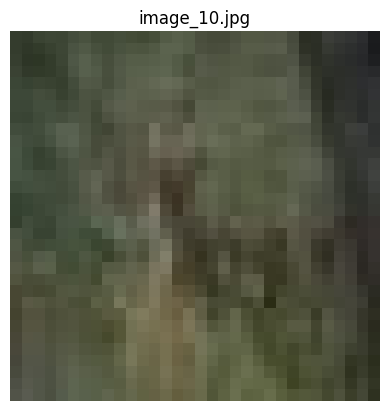

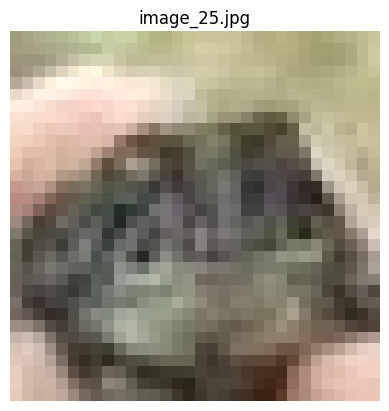

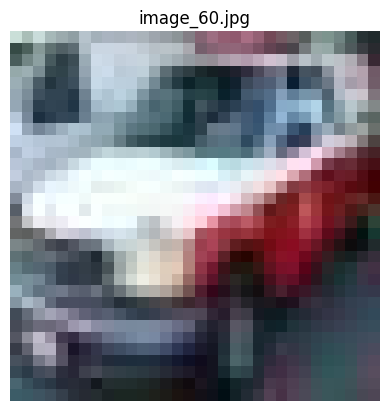

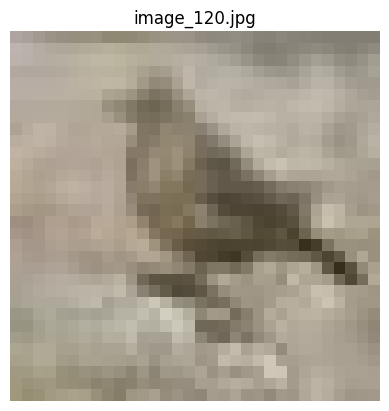

In [7]:
# Visualise the images
import matplotlib.pyplot as plt

for image_path in IMAGE_PATHS:
    img = Image.open(image_path)

    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_path.split("/")[-1])
    plt.show()

# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [13]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA Grid Training ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

GRID = [
    {"NUM_EPOCHS": 3, "LR": 1e-4, "LORA_R": 4, "LORA_ALPHA": 8},
    {"NUM_EPOCHS": 5, "LR": 1e-4, "LORA_R": 4, "LORA_ALPHA": 8},
    {"NUM_EPOCHS": 5, "LR": 5e-5, "LORA_R": 4, "LORA_ALPHA": 8},
    {"NUM_EPOCHS": 5, "LR": 1e-4, "LORA_R": 8, "LORA_ALPHA": 16},
]

BSZ_PER_DEV = 1
GRAD_ACCUM = 1
EVAL_SPLIT = 0.1
SEED = 42

MAX_SEQ_LEN = 512
SHORTEST_EDGE = 288

LORA_DROPOUT = 0.05

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


DATA_JSONL = "/content/mmai-data/train.jsonl"
MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR = "/content/cache_images"
BASE_OUTPUT_DIR = "/content/qwen_lora_grid"

LORA_TARGET = ["q_proj", "k_proj", "v_proj", "o_proj"]

FORCE_CPU = False
DTYPE_IF_GPU = torch.float16
DTYPE_IF_CPU = torch.float32

torch.manual_seed(SEED)
random.seed(SEED)

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)


# --------------------
# Dataset
# --------------------

class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path):
        self.samples = []
        with open(jsonl_path, "r") as f:
            for line in f:
                ex = json.loads(line)
                self.samples.append(ex)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


full_ds = JsonlVisionLangDataset(DATA_JSONL)

n = len(full_ds)
n_val = max(1, int(n * EVAL_SPLIT))

idx = list(range(n))
random.shuffle(idx)

val_idx = set(idx[:n_val])

train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data = [full_ds[i] for i in range(n) if i in val_idx]


class ListDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        return self.data[i]


train_ds = ListDataset(train_data)
val_ds = ListDataset(val_data)


# --------------------
# Image loader
# --------------------

def load_image(path):
    if not os.path.isabs(path):
        path = os.path.join("/content/mmai-data", path)
    return Image.open(path).convert("RGB")


# --------------------
# Collator
# --------------------

@dataclass
class VLDataCollator:
    processor: Any

    def __call__(self, features):

        images = []
        texts = []

        for ex in features:

            img = load_image(ex["image"])

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": img},
                        {"type": "text", "text": ex["question"]},
                    ],
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": ex["answer"]}],
                },
            ]

            text = self.processor.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=False,
            )

            images.append(img)
            texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )

        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        return batch


# --------------------
# Trainer
# --------------------

class FP16CLMTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.pop("labels")
        outputs = model(**inputs)

        logits = outputs.logits

        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)

        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )

        return (loss, outputs) if return_outputs else loss


# --------------------
# Device setup
# --------------------

use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None


# Load processor once
processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

collator = VLDataCollator(processor)


# ============================================================
# GRID TRAINING LOOP
# ============================================================

for i, cfg in enumerate(GRID):

    print("\n========================================")
    print("Running Experiment", i)
    print(cfg)
    print("========================================\n")

    NUM_EPOCHS = cfg["NUM_EPOCHS"]
    LR = cfg["LR"]
    LORA_R = cfg["LORA_R"]
    LORA_ALPHA = cfg["LORA_ALPHA"]

    OUTPUT_DIR = f"{BASE_OUTPUT_DIR}/exp_{i}"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Load model fresh for each run
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        dtype=torch_dtype,
        device_map=device_map,
        low_cpu_mem_usage=True,
        trust_remote_code=True,
    )

    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()
    model.config.use_cache = False

    # LoRA config
    lora_cfg = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        target_modules=LORA_TARGET,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        task_type="CAUSAL_LM",
    )

    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()

    args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BSZ_PER_DEV,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        logging_steps=1,
        fp16=use_cuda,
        report_to=[],
        remove_unused_columns=False,
    )

    trainer = FP16CLMTrainer(
        model=model,
        args=args,
        data_collator=collator,
        train_dataset=train_ds,
        eval_dataset=val_ds,
    )

    trainer.train()

    trainer.model.save_pretrained(OUTPUT_DIR)
    processor.save_pretrained(OUTPUT_DIR)

    print("\nFinished experiment", i)
    print("Saved to:", OUTPUT_DIR)


Running Experiment 0
{'NUM_EPOCHS': 3, 'LR': 0.0001, 'LORA_R': 4, 'LORA_ALPHA': 8}



Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Step,Training Loss
1,9.413857
2,9.740558
3,9.386685
4,9.357381
5,9.216721
6,8.863746
7,8.858104
8,8.759430
9,8.451941
10,8.548094


...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

trainable params: 3,686,400 || all params: 3,758,309,376 || trainable%: 0.0981


Step,Training Loss
1,9.413857
2,9.740558
3,9.386685
4,9.252518
5,9.010729
6,8.514942
7,8.335831
8,8.089824
9,7.662132
10,7.610313



Finished experiment 3
Saved to: /content/qwen_lora_grid/exp_3


In [16]:
# Identify the best model
BASE_DIR = "/content/qwen_lora_grid"

best_exp = None
best_loss = float("inf")

for exp in sorted(os.listdir(BASE_DIR)):

    exp_path = os.path.join(BASE_DIR, exp)

    if not os.path.isdir(exp_path):
        continue

    # find checkpoint folder
    checkpoints = [d for d in os.listdir(exp_path) if d.startswith("checkpoint")]

    if len(checkpoints) == 0:
        print(f"{exp}: no checkpoint found")
        continue

    ckpt_path = os.path.join(exp_path, checkpoints[0])
    state_file = os.path.join(ckpt_path, "trainer_state.json")

    if not os.path.exists(state_file):
        print(f"{exp}: trainer_state.json missing")
        continue

    with open(state_file) as f:
        state = json.load(f)

    losses = [x["loss"] for x in state["log_history"] if "loss" in x]

    if len(losses) == 0:
        print(f"{exp}: no losses recorded")
        continue

    final_loss = losses[-1]

    print(f"{exp}: final loss = {final_loss}")

    if final_loss < best_loss:
        best_loss = final_loss
        best_exp = exp

print("\nBest experiment:", best_exp)
print("Best loss:", best_loss)

BEST_MODEL_PATH = os.path.join(BASE_DIR, best_exp)
print("Best model path:", BEST_MODEL_PATH)

exp_0: final loss = 1.3076075315475464
exp_1: final loss = 1.3392564058303833
exp_2: final loss = 1.3465876579284668
exp_3: final loss = 1.3370217084884644

Best experiment: exp_0
Best loss: 1.3076075315475464
Best model path: /content/qwen_lora_grid/exp_0


# **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

3. Why do you think that is?



# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [18]:

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel

base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

ft_model = PeftModel.from_pretrained(base, BEST_MODEL_PATH)

ft_model.eval()

print("LoRA adapters loaded. Ready for inference.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.



Image: /content/mmai-data/images/image_10.jpg


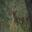

Fine-tuned Model Output: system
You are a helpful assistant.
user
What object is shown in this image? Answer with a single label.
assistant
deer

Image: /content/mmai-data/images/image_25.jpg


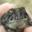

Fine-tuned Model Output: system
You are a helpful assistant.
user
What object is shown in this image? Answer with a single label.
assistant
frog

Image: /content/mmai-data/images/image_60.jpg


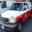

Fine-tuned Model Output: system
You are a helpful assistant.
user
What object is shown in this image? Answer with a single label.
assistant
automobile

Image: /content/mmai-data/images/image_120.jpg


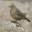

Fine-tuned Model Output: system
You are a helpful assistant.
user
What object is shown in this image? Answer with a single label.
assistant
bird


In [19]:
from IPython.display import display
import PIL.Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

TEST_IMAGES = [
    "/content/mmai-data/images/image_10.jpg",
    "/content/mmai-data/images/image_25.jpg",
    "/content/mmai-data/images/image_60.jpg",
    "/content/mmai-data/images/image_120.jpg",
]

TEST_QUESTION = "What object is shown in this image? Answer with a single label."
MAX_NEW_TOKENS = 32

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

for img_path in TEST_IMAGES:

    # Load image
    loaded_img = PIL.Image.open(img_path).convert("RGB")

    print("\n==============================")
    print("Image:", img_path)

    display(loaded_img)

    # Prepare messages
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": loaded_img},
            {"type": "text", "text": TEST_QUESTION}
        ]
    }]

    # Encode prompt
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[loaded_img],
        return_tensors="pt"
    ).to(ft_model.device)

    # Generate prediction
    with torch.no_grad():
        out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

    # Decode output
    output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]

    print("Fine-tuned Model Output:", output_text)

# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?